In [16]:
import warnings
from pathlib import Path

import prism

from imagematerials.factory import ModelFactory
from imagematerials.maintenance import Maintenance
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
)
from imagematerials.preprocessing import get_preprocessing_data


In [17]:
# Define paths
scenario_base_path = Path("..", "data", "raw")
CP_scenario_path = Path("..", "data", "raw", "image", "SSP2_baseline")
CE_scenario_path = scenario_base_path / 'circular_economy_scenarios'

In [18]:
vhc_sector = get_preprocessing_data("vehicles", scenario_base_path, 
                                    climate_policy_scenario_dir = CP_scenario_path, 
                                    circular_economy_scenario_dirs = None)


In [44]:
vhc_sector.prep_data.get("lifetimes")

{'weibull': <xarray.DataArray (Time: 294, Type: 1, ScipyParam: 2)> Size: 5kB
 array([[[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
 ...
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]],
 
        [[ 2.01, 16.07]]])
 Coordinates:
   * Time        (Time) int64 2kB 1807 1808 1809 1810 ... 2097 2098 2099 2100
   * Type        (Type) <U4 16B 'Cars'
   * ScipyParam  (ScipyParam) <U5 40B 'c' 'scale'
 Attributes:
     loc:      0,
 'folded_norm': <xarray.DataArray (Time: 294, Type: 16, ScipyParam: 2)> Size: 75kB
 array([[[ 71.17437722,   0.281     ],
         [ 74.73309609,

In [19]:
# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

In [20]:
factory = ModelFactory(
    vhc_sector, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials
    ).add(Maintenance
    )
model = factory.finish()

In [21]:
warnings.filterwarnings("ignore")
model.simulate(simulation_timeline)

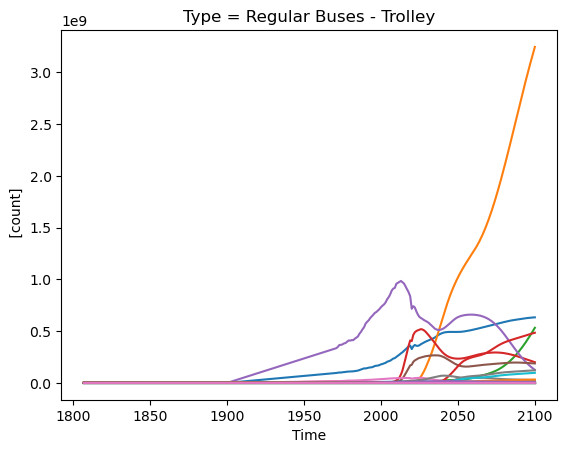

In [22]:
model.vehicles.get("stocks").sum("Region")

for type in model.vehicles.get("stocks").coords["Type"].values:
    model.vehicles.get("stocks").sel(Type=type).sum("Region").plot(label = type)

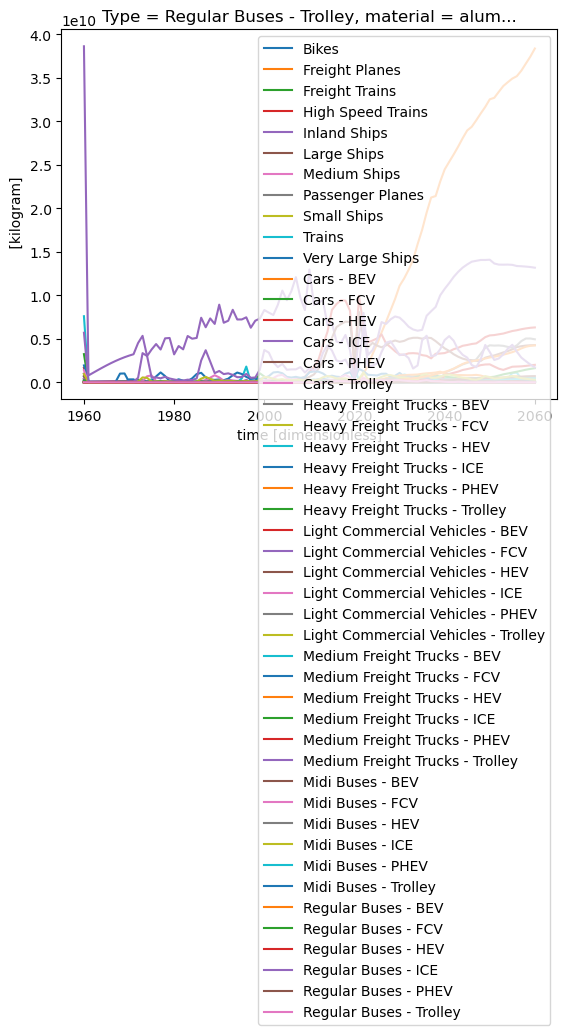

In [23]:
import matplotlib.pyplot as plt
alu = model.vehicles.get("inflow_materials").to_array().sel(material = "aluminium").sum('Region')

for type in model.vehicles.get("inflow_materials").to_array().coords["Type"].values:
    alu.sel(Type=type).plot(label = type)

plt.legend()